In [1]:
import numpy as np
import cv2
from skimage import color, io, filters
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import math
import matplotlib.image as mpimg
from skimage.metrics import structural_similarity as ssim
import warnings

# MSRCR Algorithm

In [2]:
sigma: [15,80,250]
weights: [1,1,1]
alpha: 125
beta: 46
high_clip: 0.001
low_clip: 0.001
gamma: 0.6

In [3]:
def single_scale_Retinex(raw_img, sigma):
    log_img = np.log10(raw_img) - np.log10(cv2.GaussianBlur(raw_img, (0, 0), sigma)) # sigma = 15
    return log_img


In [4]:
def multi_scale_Retinex(raw_img, sigma_arr, weight_arr):
    while len(weight_arr) < len(sigma_arr):
        weight_arr.append(0)
    weight_sum = sum(weight_arr)

    img = np.zeros(raw_img.shape)
    for i in range(len(sigma_arr)):
        w = weight_arr[i] / weight_sum
        img += single_scale_Retinex(raw_img, sigma_arr[i]) * w
    
    return img

In [5]:
def create_gamma_lookup_table(gamma):
    lut = list(range(0, 256))
    if gamma != 0:
        for i in range(0,256):
            lut[i] = int((i / 255) ** (1 / gamma) * 255)
    return lut



def quantify_log_image(img, high_clip=0.005, low_clip=0.005, gamma=0.45):
    lut = create_gamma_lookup_table(gamma)

    for c in range(img.shape[-1]):
        flatten = sorted(img[:,:,c].ravel())
        low = flatten[int(len(flatten) * low_clip)]
        high = flatten[int(len(flatten) * (1 - high_clip))]
        # plt.hist(flatten, 200, [min(flatten), max(flatten)])
        # plt.show()
        temp = np.minimum(np.maximum(img[:,:,c], low), high)
        temp = np.uint8((temp - low) / (high - low) * 255.0)

        # Gamma correction.
        if gamma != 0:
            for i in range(temp.shape[0]):
                for j in range(temp.shape[1]):
                    temp[i][j] = lut[temp[i][j]]
                
        img[:,:,c] = temp

    return np.uint8(img)

def MSR_color_restoration(original_img, sigma_arr, weight_arr, alpha=125, beta=46, high_clip=0.005, low_clip=0.005,gamma=0.45):
    original_img = np.float64(original_img) + 1.0 # Avoiding numerical unstability cause by log(0) in SSR

    # Basic Multiscale Retinex
    R = multi_scale_Retinex(original_img, sigma_arr, weight_arr)

    # Calculate color restoration function(CRF)
    sigmaI = original_img.sum(axis=2)
    # Expand dims to 3 channels, copy data at (1080,1920,0) along 2nd axis. Expanditure is required for the 2nd axis does not exist.
    sigmaI = np.expand_dims(sigmaI, axis=2).repeat(3, axis=2)
    CRF = beta * (np.log10(alpha * original_img) - np.log10(sigmaI))

    # Quantify
    img = quantify_log_image(CRF * R, high_clip, low_clip, gamma)

    # # Grayscale histogram for testing
    # plt.hist(img[:,:,0].ravel(), 200, [img[:,:,0].min(), img[:,:,0].max()])
    # plt.show()
    
    return img


# Metrics Calculation

In [6]:
def get_uiqm(a):
    rgb = a
    lab = color.rgb2lab(a)
    gray = color.rgb2gray(a)

    # UIQM
    p1 = 0.0282
    p2 = 0.2953
    p3 = 3.5753

    #1st term UICM
    rg = rgb[:,:,0] - rgb[:,:,1]
    yb = (rgb[:,:,0] + rgb[:,:,1]) / 2 - rgb[:,:,2]
    rgl = np.sort(rg,axis=None)
    ybl = np.sort(yb,axis=None)
    al1 = 0.1
    al2 = 0.1
    T1 = np.int(al1 * len(rgl))
    T2 = np.int(al2 * len(rgl))
    rgl_tr = rgl[T1:-T2]
    ybl_tr = ybl[T1:-T2]

    urg = np.mean(rgl_tr)
    s2rg = np.mean((rgl_tr - urg) ** 2)
    uyb = np.mean(ybl_tr)
    s2yb = np.mean((ybl_tr- uyb) ** 2)

    uicm =-0.0268 * np.sqrt(urg**2 + uyb**2) + 0.1586 * np.sqrt(s2rg + s2yb)

    #2nd term UISM (k1k2=8x8)
    Rsobel = rgb[:,:,0] * filters.sobel(rgb[:,:,0])
    Gsobel = rgb[:,:,1] * filters.sobel(rgb[:,:,1])
    Bsobel = rgb[:,:,2] * filters.sobel(rgb[:,:,2])

    Rsobel=np.round(Rsobel).astype(np.uint8)
    Gsobel=np.round(Gsobel).astype(np.uint8)
    Bsobel=np.round(Bsobel).astype(np.uint8)

    Reme = eme(Rsobel)
    Geme = eme(Gsobel)
    Beme = eme(Bsobel)

    uism = 0.299 * Reme + 0.587 * Geme + 0.114 * Beme

    #3rd term UIConM
    uiconm = logamee(gray)

    uiqm = p1 * uicm + p2 * uism + p3 * uiconm
    return uiqm

def eme(ch,blocksize=8):

    num_x = math.ceil(ch.shape[0] / blocksize)
    num_y = math.ceil(ch.shape[1] / blocksize)
    
    eme = 0
    w = 2. / (num_x * num_y)
    for i in range(num_x):

        xlb = i * blocksize
        if i < num_x - 1:
            xrb = (i+1) * blocksize
        else:
            xrb = ch.shape[0]

        for j in range(num_y):

            ylb = j * blocksize
            if j < num_y - 1:
                yrb = (j+1) * blocksize
            else:
                yrb = ch.shape[1]
            
            block = ch[xlb:xrb,ylb:yrb]

            blockmin = np.float(np.min(block))
            blockmax = np.float(np.max(block))

            # # old version
            # if blockmin == 0.0: eme += 0
            # elif blockmax == 0.0: eme += 0
            # else: eme += w * math.log(blockmax / blockmin)

            # new version
            if blockmin == 0: blockmin+=1
            if blockmax == 0: blockmax+=1
            eme += w * math.log(blockmax / blockmin)
    return eme

def plipsum(i,j,gamma=1026):
    return i + j - i * j / gamma

def plipsub(i,j,k=1026):
    return k * (i - j) / (k - j)

def plipmult(c,j,gamma=1026):
    return gamma - gamma * (1 - j / gamma)**c

def logamee(ch,blocksize=8):

    num_x = math.ceil(ch.shape[0] / blocksize)
    num_y = math.ceil(ch.shape[1] / blocksize)
    
    s = 0
    w = 1. / (num_x * num_y)
    for i in range(num_x):

        xlb = i * blocksize
        if i < num_x - 1:
            xrb = (i+1) * blocksize
        else:
            xrb = ch.shape[0]

        for j in range(num_y):

            ylb = j * blocksize
            if j < num_y - 1:
                yrb = (j+1) * blocksize
            else:
                yrb = ch.shape[1]
            
            block = ch[xlb:xrb,ylb:yrb]
            blockmin = np.float(np.min(block))
            blockmax = np.float(np.max(block))

            top = plipsub(blockmax,blockmin)
            bottom = plipsum(blockmax,blockmin)

            m = top/bottom
            if m ==0.:
                s+=0
            else:
                s += (m) * np.log(m)

    return plipmult(w,s)


In [7]:
def get_entropy(img_):
    x, y = img_.shape[0:2]
    tmp = []
    for i in range(256):
        tmp.append(0)
    val = 0
    k = 0
    res = 0
    img = np.array(img_)
    for i in range(len(img)):
        for j in range(len(img[i])):
            val = img[i][j]
            tmp[val] = float(tmp[val] + 1)
            k =  float(k + 1)
    for i in range(len(tmp)):
        tmp[i] = float(tmp[i] / k)
    for i in range(len(tmp)):
        if(tmp[i] == 0):
            res = res
        else:
            res = float(res - tmp[i] * (math.log(tmp[i]) / math.log(2.0)))
    return res

Enter the images to process:image1.jpg


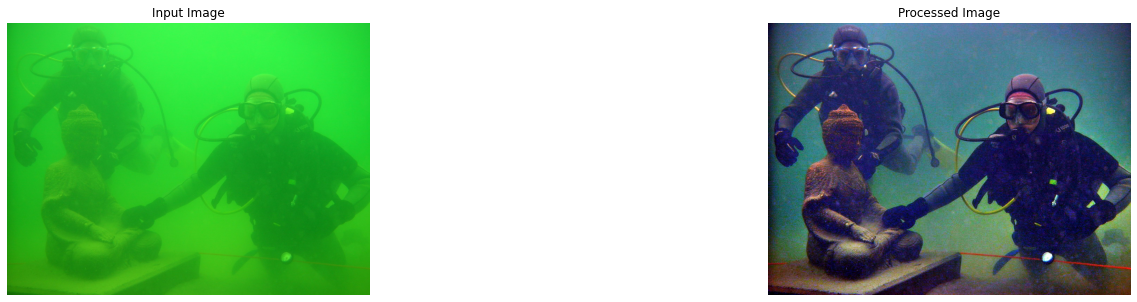

PSNR =  10.340421033318087
SSIM =  0.5807149724479846
Information Entropy =  7.0908946953376155
UIQM =  0.812254317225009
Average PSNR =  10.340421033318087
Average SSIM =  0.5807149724479846
Average Information Entropy =  7.0908946953376155
Average UIQM =  0.812254317225009


In [8]:
inpath = r'C:\Users\user-name\folder-name\images'
outpath = r'C:\Users\user-name\folder-name\MSRCR_OUTPUT'
a_uiqm = a_psnr = a_ssim = a_entropy = count =0
images = input("Enter the images to process:").split()
for i in images:
    name,ext = i.split(".")
    j = "\\"+i
    plt.figure(figsize=(25,5))
    
    img = cv2.imread(inpath+j)
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    
    # Applying MSRCR
    processed_img = MSR_color_restoration(img,[15,80,250], [1,1,1],125,46,0.001,0.001,0.6)
    processed_img = cv2.cvtColor(processed_img,cv2.COLOR_RGB2BGR)
    cv2.imwrite(outpath+j,processed_img)
    
    
    plt.subplot(121)
    plt.axis('off')
    plt.imshow(mpimg.imread(inpath+j))
    plt.title("Input Image")
    
    plt.subplot(122)
    plt.axis('off')
    plt.imshow(mpimg.imread(outpath+j))
    plt.title("Processed Image")
    
    plt.show()
    
    # Calculating PSNR, SSIM, Information Entropy,UIQM
    count+=1
    
    input_image = Image.open(inpath+j)
    input_image = cv2.cvtColor(np.array(input_image),cv2.COLOR_RGB2BGR)
    
    processed_image = Image.open(outpath+j)
    processed_image = cv2.cvtColor(np.array(processed_image),cv2.COLOR_RGB2BGR)
    
    entropy = get_entropy(cv2.imread(outpath+j,0))
    
    warnings.filterwarnings('ignore')
    uiqm = get_uiqm(io.imread(outpath+j))
    
    
    psnr = cv2.PSNR(processed_image,input_image)
    SSIM = ssim(cv2.cvtColor(processed_image,cv2.COLOR_BGR2GRAY),cv2.cvtColor(input_image,cv2.COLOR_BGR2GRAY))
    
    print("PSNR = ",psnr)
    print("SSIM = ",SSIM)
    print("Information Entropy = ",entropy)
    print("UIQM = ",uiqm)
    
    a_psnr = a_psnr + psnr
    a_ssim = a_ssim + SSIM
    a_entropy = a_entropy + entropy
    a_uiqm = a_uiqm + uiqm
    

print("Average PSNR = ",(a_psnr/count))
print("Average SSIM = ",(a_ssim/count))
print("Average Information Entropy = ",(a_entropy/count))
print("Average UIQM = ",(a_uiqm/count))    